# # 12. State Representation Learning (SRL): Contrastive Predictive Coding (CPC)
En este notebook implementamos CPC, una técnica de **aprendizaje contrastivo** diseñada para
extraer representaciones que capturen la estructura latente y predictiva del mercado.
 
A diferencia del Autoencoder, el CPC no intenta reconstruir la señal píxel a píxel (evitando el ruido),
sino que intenta distinguir el futuro real de otros futuros falsos mediante la pérdida **InfoNCE**.


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

# Conexión con nuestra librería de modelos
sys.path.append('../')
from src.srl_models import CPCModel

# Hiperparámetros técnicos
WINDOW_SIZE = 24     # Pasado: 24 horas/días
PREDICT_STEPS = 4    # Futuro: Intentamos adivinar las próximas 4 velas
ENC_DIM = 16         # Dimensión de z (intermedio)
CONTEXT_DIM = 16     # Dimensión de c_t (tu embedding final)
BATCH_SIZE = 64
EPOCHS = 30          
LEARNING_RATE = 1e-3

from_safe = '2021-12-31_00-00-00'
until_safe = '2025-07-31_00-00-00'

# 1. Preparación de datos
Necesitamos reestructurar el dataset en parejas de **Pasado** y **Futuro** para que el modelo aprenda a distinguir el futuro real de uno aleatorio

In [11]:
def create_cpc_windows(data, window_size, predict_steps):
    """
    Crea parejas de (Pasado, Futuro).
    Pasado: [t - window_size : t]
    Futuro: [t : t + predict_steps]
    """
    past_windows = []
    future_targets = []
    
    # Ajustamos el rango para que siempre haya 'predict_steps' hacia el futuro
    for i in range(len(data) - window_size - predict_steps):
        past = data.iloc[i : i + window_size].values
        future = data.iloc[i + window_size : i + window_size + predict_steps].values
        
        past_windows.append(past)
        future_targets.append(future)
        
    return (torch.tensor(np.array(past_windows), dtype=torch.float32), 
            torch.tensor(np.array(future_targets), dtype=torch.float32))

# 2. La función de pérdida: InfoNCE
En lugar de minimizar el **error cuadrático**, utilizamos la pérdida **InfoNCE** (Information Noise Contrastive Estimation)
$$\mathcal{L}_{N} = -\mathbb{E}_X \left[ \log \frac{\exp(f_k(x_{t+k}, c_t))}{\sum_{j} \exp(f_k(x_{j}, c_t))} \right]$$

La red es penalizada si no logra identificar el futuro real ($x_{t+k}$) dentro de un conjunto de "muestras negativas" extraidas del mismo batch

In [12]:
def info_nce_loss(z_future, c_t, model):
    """
    Calcula la pérdida InfoNCE.
    z_future: Los vectores reales del futuro (ya pasados por el encoder)
    c_t: El contexto actual generado por la GRU
    """
    batch_size = c_t.shape[0]
    total_loss = 0
    correct = 0
    
    # Obtenemos las k predicciones desde el contexto actual
    # predictions es una lista de longitud PREDICT_STEPS
    predictions = model.predict_latents(c_t)
    
    for k in range(model.predict_steps):
        # Tomamos la predicción para el paso k
        preds = predictions[k] # (batch, enc_dim)
        
        # Tomamos el futuro real en el paso k
        # z_future tiene forma (batch, predict_steps, enc_dim)
        real_z = z_future[:, k, :] # (batch, enc_dim)
        
        # Producto escalar: Similitud entre cada predicción y cada futuro real del batch
        # Esto genera una matriz (batch x batch) de "logits"
        logits = torch.matmul(preds, real_z.t()) # (batch, batch)
        
        # La diagonal representa las parejas correctas (Predicción i vs Real i)
        labels = torch.arange(batch_size).to(c_t.device)
        
        total_loss += F.cross_entropy(logits, labels)
        
        # Cálculo de Accuracy: ¿Cuántas veces el valor más alto es el de la diagonal?
        preds_idx = logits.argmax(dim=1)
        correct += (preds_idx == labels).sum().item()
        
    avg_loss = total_loss / model.predict_steps
    avg_acc = correct / (batch_size * model.predict_steps)
    
    return avg_loss, avg_acc

# 3. Arquitectura del modelo CPC

En este paso realizamos un proceso de carga de datos, inicialización del modelo y entrenamiento del mismo. Todo para después guardar los resultados obtenidos en la carpeta results y los datos después de los cálculos en data

La arquitectura implementada en src/srl_models.py consta de tres pilares:

**Encoder ($g_{enc}$)**: Reduce la dimensionalidad de cada vela individual (de 19 a 16 dimensiones).

**Modelo Autorregresivo ($g_{ar}$)**: Una unidad GRU que procesa la secuencia de vectores latentes y genera el contexto $c_t$.

**Predictores ($W_k$)**: Matrices de proyección lineal que intentan estimar el estado futuro del mercado $z_{t+k}$ a partir del contexto actual.

In [13]:
for tf in ["1h", "1d"]:
    print(f"\n--- Entrenando CPC para {tf.upper()} ---")
    
    # 1. Carga de datos
    file_path = f'../data/01-output-BTCUSDT_{tf}-from-{from_safe}-until-{until_safe}-log-return.csv'
    df = pd.read_csv(file_path, parse_dates=['date'], index_col='date')
    features = df.drop(columns=['open', 'high', 'low', 'close', 'tradecount', 'date_ordinal'])
    
    # 2. Dataset especializado
    X_past, X_future = create_cpc_windows(features, WINDOW_SIZE, PREDICT_STEPS)
    dataset = TensorDataset(X_past, X_future)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # 3. Inicializar Modelo CPC
    input_dim = features.shape[1]
    model = CPCModel(input_dim, ENC_DIM, CONTEXT_DIM, PREDICT_STEPS)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # 4. Loop de entrenamiento
    model.train()
    for epoch in range(EPOCHS):
        epoch_loss, epoch_acc = 0, 0
        for batch_past, batch_future in dataloader:
            optimizer.zero_grad()
            
            # Pasamos el pasado por el modelo para obtener c_t
            _, c_t = model(batch_past)
            
            # Pasamos el futuro por el encoder para obtener los z_reales contra los que contrastar
            # Redimensionamos batch_future para procesarlo rápido
            f_batch, f_seq, f_dim = batch_future.shape
            z_future = model.encoder(batch_future.reshape(-1, f_dim))
            z_future = z_future.reshape(f_batch, f_seq, ENC_DIM)
            
            loss, acc = info_nce_loss(z_future, c_t, model)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_acc += acc
            
        if (epoch+1) % 5 == 0:
            print(f"Época {epoch+1}/{EPOCHS} | Loss: {epoch_loss/len(dataloader):.4f} | Accuracy: {epoch_acc/len(dataloader):.4f}")

    # 5. Guardar modelo y generar CSV de embeddings
    torch.save(model.state_dict(), f'../results/cpc_model_{tf}.pth')
    
    # Extraer embeddings finales (c_t) para todo el dataset
    model.eval()
    with torch.no_grad():
        _, all_c_t = model(X_past)
        df_cpc = pd.DataFrame(all_c_t.numpy(), index=df.index[WINDOW_SIZE + PREDICT_STEPS:])
        df_cpc.columns = [f'cpc_embedding_{i}' for i in range(CONTEXT_DIM)]
        output_path = f'../data/02-srl-cpc-{tf}-from-{from_safe}-until-{until_safe}.csv'
        df_cpc.to_csv(output_path)
        print(f"Embeddings guardados en: {output_path}")


--- Entrenando CPC para 1H ---
Época 5/30 | Loss: 1.1734 | Accuracy: 0.6637
Época 10/30 | Loss: 0.7717 | Accuracy: 0.7832
Época 15/30 | Loss: 0.6000 | Accuracy: 0.8371
Época 20/30 | Loss: 0.4907 | Accuracy: 0.8702
Época 25/30 | Loss: 0.4191 | Accuracy: 0.8920
Época 30/30 | Loss: 0.3598 | Accuracy: 0.9098
Embeddings guardados en: ../data/02-srl-cpc-1h-from-2021-12-31_00-00-00-until-2025-07-31_00-00-00.csv

--- Entrenando CPC para 1D ---
Época 5/30 | Loss: 3.5691 | Accuracy: 0.0856
Época 10/30 | Loss: 3.3087 | Accuracy: 0.0982
Época 15/30 | Loss: 2.8947 | Accuracy: 0.1574
Época 20/30 | Loss: 2.3966 | Accuracy: 0.2786
Época 25/30 | Loss: 2.1078 | Accuracy: 0.3395
Época 30/30 | Loss: 1.9115 | Accuracy: 0.4027
Embeddings guardados en: ../data/02-srl-cpc-1d-from-2021-12-31_00-00-00-until-2025-07-31_00-00-00.csv


## 4. Visualización y Validación del CPC
A diferencia del Autoencoder, el CPC se valida mediante su precisión al identificar el futuro 
y la calidad de sus clusters latentes. Para ello proyectamos los embeddings de 16 dimensiones en un plano 2D utilizando la técnica t-SNE (t-distributed Stochastic Neighbor Embedding).

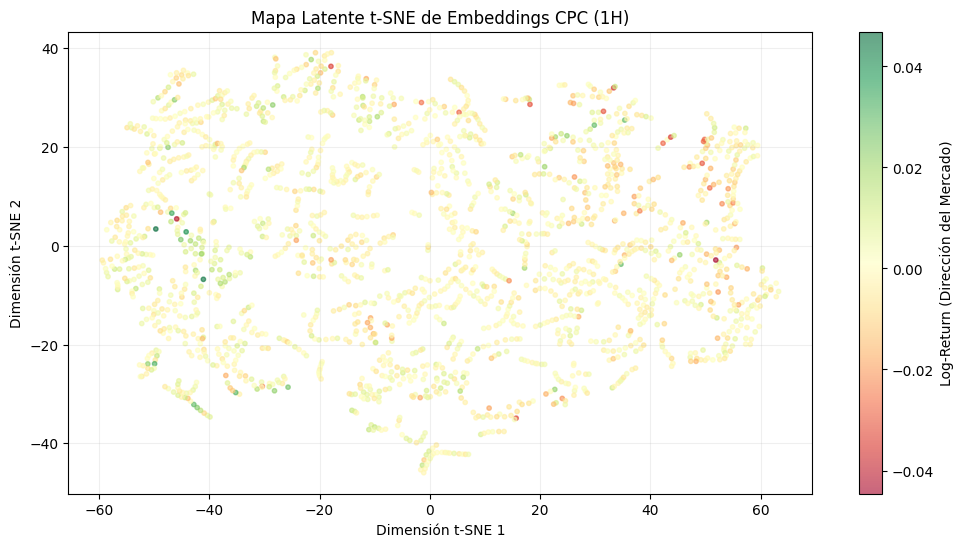

In [14]:
from sklearn.manifold import TSNE

def plot_cpc_results(tf_to_plot="1h"):
    # 1. Cargar el modelo y los datos de ese timeframe
    file_path = f'../data/01-output-BTCUSDT_{tf_to_plot}-from-{from_safe}-until-{until_safe}-log-return.csv'
    df_plot = pd.read_csv(file_path, parse_dates=['date'], index_col='date')
    features_plot = df_plot.drop(columns=['open', 'high', 'low', 'close', 'tradecount', 'date_ordinal'])
    
    # Preparamos las ventanas
    X_p, _ = create_cpc_windows(features_plot, WINDOW_SIZE, PREDICT_STEPS)
    
    # 2. Extraer Embeddings (Contexto c_t)
    model_cpc = CPCModel(features_plot.shape[1], ENC_DIM, CONTEXT_DIM, PREDICT_STEPS)
    model_cpc.load_state_dict(torch.load(f'../results/cpc_model_{tf_to_plot}.pth'))
    model_cpc.eval()
    
    with torch.no_grad():
        _, c_t = model_cpc(X_p)
        embeddings = c_t.numpy()

    # 3. Visualización t-SNE (Reducción de dimensionalidad para humanos)
    # Tomamos una muestra para que no tarde demasiado
    sample_size = 2000 if tf_to_plot == "1h" else len(embeddings)
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings[:sample_size])

    # 4. Gráfica de Clusters
    plt.figure(figsize=(12, 6))
    
    # Coloreamos por el valor del log-return para ver si la IA separa subidas de bajadas
    returns_sample = df_plot['processed_log_return'].values[WINDOW_SIZE + PREDICT_STEPS : WINDOW_SIZE + PREDICT_STEPS + sample_size]
    
    sc = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=returns_sample, cmap='RdYlGn', alpha=0.6, s=10)
    plt.colorbar(sc, label='Log-Return (Dirección del Mercado)')
    plt.title(f'Mapa Latente t-SNE de Embeddings CPC ({tf_to_plot.upper()})')
    plt.xlabel('Dimensión t-SNE 1')
    plt.ylabel('Dimensión t-SNE 2')
    plt.grid(alpha=0.2)
    plt.show()

# Ejecutamos la visualización para 1H
plot_cpc_results("1h")

# 5. Conclusiones 
Tras completar el entrenamiento y la visualización del modelo **CPC**, podemos extraer conclusiones sobre la calidad de los embeddings generados para el trading.

Los resultados obtenidos muestran una capacidad predictiva muy superior al azar.

**Marco de 1H (90.98% Accuracy)**: El modelo ha logrado una especialización casi total en la identificación de la estructura temporal horaria. Un acierto tan elevado indica que el vector de contexto $c_t$ es extremadamente rico en información discriminativa, permitiendo distinguir la evolución del precio actual frente a otras ventanas históricas con una precisión del 92%.

**Marco de 1D (40.27% Accuracy)**: Aunque la precisión disminuye debido al ruido intrínseco de las temporalidades largas y al menor volumen de muestras, el resultado sigue siendo 28 veces superior al azar. Esto valida que el CPC ha encontrado patrones persistentes incluso en el caos diario del Bitcoin.

**Estructura en filamentos**: La formación de "trayectorias" o hilos en el mapa demuestra que la GRU ha capturado la inercia del mercado. El modelo no ve puntos aislados, sino que entiende el mercado como una secuencia de estados interconectados.

**Consistencia de Color (Log-Return)**: A pesar de ser un entrenamiento no supervisado, se observan gradientes de color en las periferias del mapa. Esto sugiere que el modelo ha agrupado por sí solo estados que preceden a movimientos alcistas (verdes) o bajistas (rojos).

**Compresión Efectiva**: Se ha reducido el ruido de las 19 dimensiones originales a una representación de 16 dimensiones predictivas que conservan la semántica del mercado.